In [1]:
from MDToolkit.IO.read_file import pdb_file_to_structured_system, lammps_data_file_to_structured_system, lammps_dump_file_to_simulation
from MDToolkit.IO.write_file import write_lammps_structure_file_atomic_full
from MDToolkit.analysis.diffusivity import compute_MSD

lammps_dump_file = "/media/jrjoseph/Elements/projects/training/water_box_ls6/water_box_nvt_prod.out"

type_map = {1 : "O", 2 : "H"}

simulation = lammps_dump_file_to_simulation(lammps_dump_file, type_map, "unwrapped")

Processing frames:   0%|          | 0/1001 [00:00<?, ?frame/s]

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_msd(
    msd_data,
    axes = ["x", "y", "z", "sum"],
    show_std = True,
    std_label = "Std Dev",
    ax = None
):
    '''
    Plots MSD vs time with optional uncertainty shading.
    '''

    if ax is None:
        fig, ax = plt.subplots()

    t = msd_data["timesteps"]

    color_map = {
        "x": "C0",
        "y": "C1",
        "z": "C2",
        "sum": "C3"
    }

    key_map = {
        "x": ("x_msd", "x_std"),
        "y": ("y_msd", "y_std"),
        "z": ("z_msd", "z_std"),
        "sum": ("sum_msd", "sum_std")
    }

    for axis in axes:
        mean_key, std_key = key_map[axis]

        ax.plot(
            t,
            msd_data[mean_key],
            label=f"{axis}-MSD",
            color=color_map.get(axis, None)
        )

        if show_std:
            ax.fill_between(
                t,
                msd_data[mean_key] - msd_data[std_key],
                msd_data[mean_key] + msd_data[std_key],
                alpha=0.25,
                color=color_map.get(axis, None),
                label=f"{axis} {std_label}"
            )

    ax.set_xlabel("Time Step")
    ax.set_ylabel("MSD ($\mathrm{\AA^2}$)")
    ax.legend()

    return ax

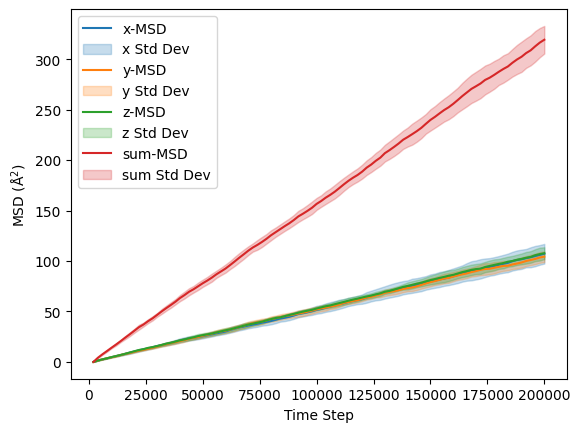

In [6]:
msd_data = compute_MSD(simulation, 10)

plot_msd(msd_data)
plt.show()

In [10]:
# Diffusivity from MSD

coefficients, cov_matrix = np.polyfit(msd_data["timesteps"], msd_data["sum_msd"], deg=1, cov=True)

slope = coefficients[0]

# The standard deviation of the coefficients is the square root of the diagonal
slope_std_dev = np.sqrt(cov_matrix[0, 0])

print(f"D (m2/s): {slope * 10**(15) / 10**(20) * 1/6}")
print(f"D std dev: {slope_std_dev * 10**(15) / 10**(20) * 1/6}")

D (m2/s): 2.6812734283061694e-09
D std dev: 3.549059734542718e-12
